In [1]:
!pip install earthengine-api
!pip install geemap
!pip install rasterio

import ee
import geemap
import os
import rasterio
import numpy as np
import datetime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 49.2 MB/s eta 0:00:00


# **Landsat 7 Data**

In [ ]:


# Authenticate and initialize Google Earth Engine
ee.Authenticate()
ee.Initialize(project="steam-house-426309-a7") #Replace project name with your own for reproducibility!

# Define region of interest (Singapore)
singapore = ee.Geometry.Point([103.8198, 1.3521])


In [ ]:


# Function to apply cloud masking using the QA band
def mask_clouds(image):
    qa = image.select('QA_PIXEL')  # Select the QA band
    cloud_mask = qa.bitwiseAnd(1 << 5).neq(0)
    cloud_shadow = qa.bitwiseAnd(1 << 3).neq(0)
    final_mask = cloud_mask.Or(cloud_shadow)

    # Apply mask: remove cloudy and shadowed pixels
    return image.updateMask(final_mask.Not())

# def get_lst(image):
#     lst_celsius = image.select('ST_B10').multiply(0.00341802).add(149.0).subtract(273.15).rename('LST')
#     return image.addBands(lst_celsius)


# Function to compute LST
def calculate_lst(image):
    # Convert Thermal Band 6 to TOA Radiance
    # Convert TOA Radiance to Brightness Temperature (Celsius)
    rad = image.select('B6_VCID_2').subtract(1).multiply(0.0554).add(1.238).rename('RAD')
    image = image.addBands(srcImg=rad, overwrite=True)
    lst = image.expression('1282.71 /log(666.09/rad + 1) - 273.15', {'rad': image.select('RAD')}).rename('LST')
    image = image.addBands(srcImg=lst, overwrite=True)
    return image.copyProperties(image, ["system:time_start"])


# Load Landsat 7 Collection 2 Level 1 dataset
landsat7 = (
    ee.ImageCollection("LANDSAT/LE07/C02/T1")
    .filterBounds(singapore)
    .filterDate("2000-01-01", "2024-12-31")
    .map(mask_clouds)
    .map(calculate_lst)
)


In [ ]:
# Convert ImageCollection to List
image_list = landsat7.toList(landsat7.size())

singapore_region = ee.FeatureCollection("projects/steam-house-426309-a7/assets/singapore_boundary")
# Function to export images with date-based filenames
def export_image(img):
    img = ee.Image(img)

    # Extract date from metadata
    date_millis = img.get("system:time_start")  # Get timestamp
    date_str = ee.Date(date_millis).format("YYYY-MM-dd").getInfo()  # Convert to string

    task = ee.batch.Export.image.toDrive(
        image=img.select(['LST']),
        description=f"LST_Singapore_{date_str}",
        folder="GEE_landsat7",  # Google Drive folder
        fileNamePrefix=f"LST_Singapore_{date_str}",
        scale=30,  # Landsat resolution
        region=singapore_region.geometry().bounds(),  # Buffer around Singapore
        maxPixels=1e13
    )
    task.start()
    print(f"Exporting Image for {date_str}...")

# Export first 5 images (modify range if needed) landsat7.size().getInfo()
for i in range(landsat7.size().getInfo()):  # Change to landsat7.size().getInfo() for all images landsat7.size().getInfo()
    export_image(image_list.get(i))

Exporting Image for 2000-04-28...
Exporting Image for 2000-05-30...
Exporting Image for 2000-07-17...
Exporting Image for 2000-09-03...
Exporting Image for 2000-11-06...
Exporting Image for 2000-12-08...
Exporting Image for 2001-01-09...
Exporting Image for 2001-02-26...
Exporting Image for 2001-03-14...
Exporting Image for 2001-03-30...
Exporting Image for 2001-04-15...
Exporting Image for 2001-05-01...
Exporting Image for 2001-05-17...
Exporting Image for 2001-07-20...
Exporting Image for 2001-09-06...
Exporting Image for 2001-09-22...
Exporting Image for 2001-10-24...
Exporting Image for 2001-11-09...
Exporting Image for 2001-11-25...
Exporting Image for 2002-01-12...
Exporting Image for 2002-01-28...
Exporting Image for 2002-03-01...
Exporting Image for 2002-03-17...
Exporting Image for 2002-04-02...
Exporting Image for 2002-05-04...
Exporting Image for 2002-05-20...
Exporting Image for 2002-06-05...
Exporting Image for 2002-06-21...
Exporting Image for 2002-07-07...
Exporting Imag

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LST Min: 4.35 °C
LST Max: 41.08 °C
LST Mean: 25.94 °C


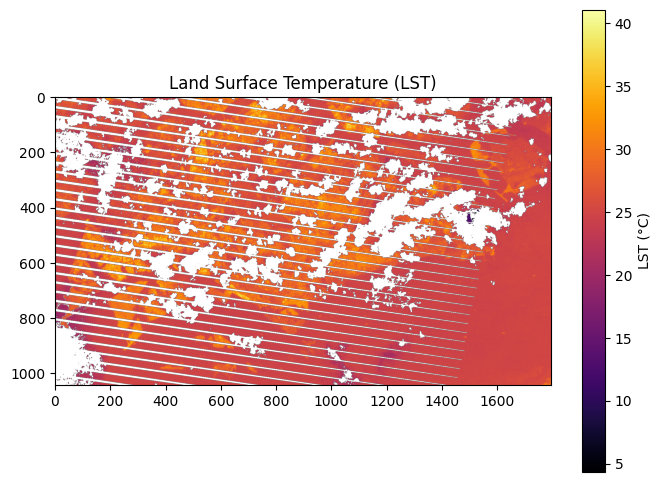

In [4]:
from google.colab import drive
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Mount Google Drive
drive.mount('/content/drive')

# Step 2: Set file path (modify if needed)
tif_path = "/content/drive/My Drive/GEE_landsat7/LST_Singapore_2005-12-06.tif"  # Update filename

# Step 3: Open the GeoTIFF file and read data
with rasterio.open(tif_path) as dataset:
    lst_data = dataset.read(1)  # Read the first (and only) band
    nodata_value = dataset.nodata  # Get NoData value

# Step 4: Remove NoData values for analysis
lst_data = np.where(lst_data == nodata_value, np.nan, lst_data)

# Step 5: Display LST statistics
print(f"LST Min: {np.nanmin(lst_data):.2f} °C")
print(f"LST Max: {np.nanmax(lst_data):.2f} °C")
print(f"LST Mean: {np.nanmean(lst_data):.2f} °C")

# Step 6: Visualize LST values
plt.figure(figsize=(8,6))
plt.imshow(lst_data, cmap="inferno")
plt.colorbar(label="LST (°C)")
plt.title("Land Surface Temperature (LST)")
plt.show()


## **Landsat 8 Data**

In [ ]:
# Authenticate and initialize Earth Engine
ee.Authenticate()
ee.Initialize(project="steam-house-426309-a7")

# Define region of interest (Singapore)
singapore = ee.Geometry.Point([103.8198, 1.3521])

def normalize_ndvi(image, band_name = 'NDVI'):
    # Compute min and max using reduceRegion
        # Compute min and max using reduceRegion
    stats = image.select(band_name).reduceRegion(
        reducer=ee.Reducer.minMax(),
        geometry=image.geometry(),
        scale=30,  # Adjust scale based on dataset resolution
        bestEffort=True,  # Prevent failures for large areas
        maxPixels=1e13
    )

    # Extract min and max, ensuring they are Numbers
    min_val = ee.Number(stats.get(band_name + '_min'))
    max_val = ee.Number(stats.get(band_name + '_max'))

    # Handle missing values properly by replacing them with default numbers
    min_val = ee.Algorithms.If(min_val, min_val, ee.Number(0))  # Ensure type remains ee.Number
    max_val = ee.Algorithms.If(max_val, max_val, ee.Number(1))  # Ensure type remains ee.Number

    # Convert to ee.Number explicitly
    min_val = ee.Number(min_val)
    max_val = ee.Number(max_val)
    # Normalize the band
    pv = image.expression(
        '((B - min) / (max - min + 1e-6))**2',  # Prevent division by zero
        {
            'B': image.select(band_name),
            'min': min_val,
            'max': max_val
        }
    ).rename('PV')

    # Add the normalized band to the image
    return image.addBands(pv)


# Function to apply cloud masking using the QA band
def mask_clouds(image):
    qa = image.select('QA_PIXEL')  # Quality Assessment band
    cloud_mask = qa.bitwiseAnd(1 << 3).neq(0) # Extract Cloud Bit
    cloud_shadow = qa.bitwiseAnd(1 << 4).neq(0)
    final_mask = cloud_mask.Or(cloud_shadow)
    return image.updateMask(final_mask.Not())


# def get_lst(image):
#     lst_celsius = image.select('ST_B10').multiply(0.00341802).add(149.0).subtract(273.15).rename('LST')
#     return image.addBands(lst_celsius)




# Function to compute LST (using Landsat 8 Band 10)
def calculate_lst(image):
    # Convert Thermal Band 10 to TOA Radiance
    rad = image.select('B10').multiply(0.0003342).add(0.1).rename('RAD')
    image = image.addBands(rad)

    # Convert TOA Radiance to Brightness Temperature (Kelvin → Celsius)
    bt = image.expression(
        'K2 / log(K1 / rad + 1) - 273.15',
        {
            'rad': image.select('RAD'),
            'K1': 774.8853,  # K1 Constant for Landsat 8
            'K2': 1321.0789   # K2 Constant for Landsat 8
        }
    ).rename('BT')
    image = image.addBands(bt)

    # Calculate NDVI
    ndvi = image.expression(
        '(B5 - B4)/(B5 + B4)',
        {
            'B5': image.select('B5'),
            'B4': image.select('B4')
        }
    ).rename('NDVI')
    image = image.addBands(ndvi)
    image = normalize_ndvi(image)


    # Compute Emissivity (E)
    e = image.expression(
        'pv * 0.004 + 0.986',
        {
            'pv': image.select('PV')
        }
    ).rename('E')
    image = image.addBands(e)

    # Compute Land Surface Temperature (LST)
    lst = image.expression(
        'bt / (1 + (bt * 10.8 / 14388) * log(e))',
        {
            'bt': image.select('BT'),
            'e': image.select('E')
        }
    ).rename('LST')

    return image.addBands([lst]).copyProperties(image, ["system:time_start"])



In [ ]:
# Load Landsat 8 Collection 2 Level 2 dataset
landsat8 = (
    ee.ImageCollection("LANDSAT/LC08/C02/T1")  # Landsat 8 Collection 2
    .filterBounds(singapore)
    .filterDate("2013-01-01", "2024-12-31")  # Landsat 8 available since 2013
    .map(mask_clouds)
    .map(calculate_lst)
)

# Convert ImageCollection to List
image_list = landsat8.toList(landsat8.size())

# Singapore boundary for export
singapore_region = ee.FeatureCollection("projects/steam-house-426309-a7/assets/singapore_boundary")

# Function to export images with date-based filenames
def export_image(img):
    img = ee.Image(img)

    # Extract date from metadata
    date_millis = img.get("system:time_start")  # Get timestamp
    date_str = ee.Date(date_millis).format("YYYY-MM-dd").getInfo()  # Convert to string

    task = ee.batch.Export.image.toDrive(
        image=img.select(['LST']),
        description=f"LST_Singapore_{date_str}",
        folder="GEE_landsat8",  # Google Drive folder
        fileNamePrefix=f"LST_Singapore_{date_str}",
        scale=30,  # Landsat 8 resolution
        region=singapore_region.geometry().bounds(),  # Buffer around Singapore
        maxPixels=1e13
    )
    task.start()
    print(f"Exporting Image for {date_str}...")

# Export first 5 images (modify range if needed)
for i in range(landsat8.size().getInfo()):  # Change to landsat8.size().getInfo() for all images landsat8.size().getInfo()
    export_image(image_list.get(i))

Exporting Image for 2013-04-24...
Exporting Image for 2013-05-26...
Exporting Image for 2013-06-11...
Exporting Image for 2013-06-27...
Exporting Image for 2013-07-13...
Exporting Image for 2013-07-29...
Exporting Image for 2013-08-30...
Exporting Image for 2013-10-01...
Exporting Image for 2013-10-17...
Exporting Image for 2013-11-02...
Exporting Image for 2014-01-21...
Exporting Image for 2014-02-06...
Exporting Image for 2014-02-22...
Exporting Image for 2014-03-10...
Exporting Image for 2014-03-26...
Exporting Image for 2014-04-11...
Exporting Image for 2014-04-27...
Exporting Image for 2014-05-13...
Exporting Image for 2014-05-29...
Exporting Image for 2014-06-14...
Exporting Image for 2014-06-30...
Exporting Image for 2014-07-16...
Exporting Image for 2014-08-01...
Exporting Image for 2014-08-17...
Exporting Image for 2014-09-02...
Exporting Image for 2014-09-18...
Exporting Image for 2014-10-04...
Exporting Image for 2014-10-20...
Exporting Image for 2014-11-05...
Exporting Imag

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LST Min: 9.42 °C
LST Max: 32.02 °C
LST Mean: 20.93 °C


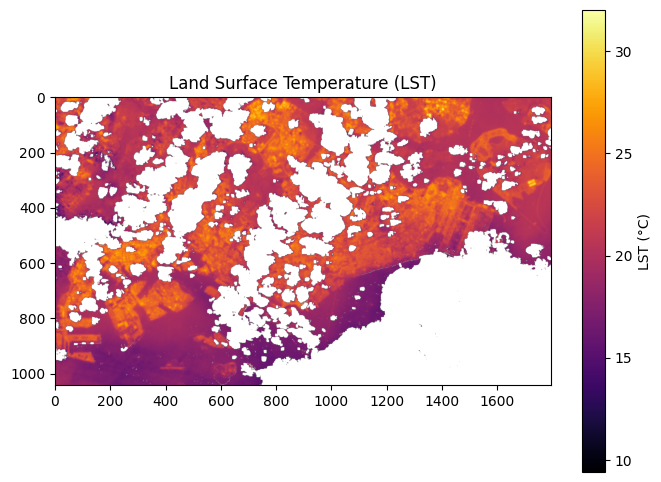

In [6]:
from google.colab import drive
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Mount Google Drive
drive.mount('/content/drive')

# Step 2: Set file path (modify if needed)
tif_path = "/content/drive/My Drive/GEE_landsat8/LST_Singapore_2024-09-13.tif"  # Update filename

# Step 3: Open the GeoTIFF file and read data
with rasterio.open(tif_path) as dataset:
    lst_data = dataset.read(1)  # Read the first (and only) band
    nodata_value = dataset.nodata  # Get NoData value

# Step 4: Remove NoData values for analysis
lst_data = np.where(lst_data == nodata_value, np.nan, lst_data)

# Step 5: Display LST statistics
print(f"LST Min: {np.nanmin(lst_data):.2f} °C")
print(f"LST Max: {np.nanmax(lst_data):.2f} °C")
print(f"LST Mean: {np.nanmean(lst_data):.2f} °C")

# Step 6: Visualize LST values
plt.figure(figsize=(8,6))
plt.imshow(lst_data, cmap="inferno")
plt.colorbar(label="LST (°C)")
plt.title("Land Surface Temperature (LST)")
plt.show()


## **Landsat 9 Data**

In [ ]:
# Authenticate and initialize Earth Engine
ee.Authenticate()
ee.Initialize(project="steam-house-426309-a7")

# Define region of interest (Singapore)
singapore = ee.Geometry.Point([103.8198, 1.3521])





def normalize_ndvi(image, band_name = 'NDVI'):
    # Compute min and max using reduceRegion
        # Compute min and max using reduceRegion
    stats = image.select(band_name).reduceRegion(
        reducer=ee.Reducer.minMax(),
        geometry=image.geometry(),
        scale=30,  # Adjust scale based on dataset resolution
        bestEffort=True,  # Prevent failures for large areas
        maxPixels=1e13
    )

    # Extract min and max, ensuring they are Numbers
    min_val = ee.Number(stats.get(band_name + '_min'))
    max_val = ee.Number(stats.get(band_name + '_max'))

    # Handle missing values properly by replacing them with default numbers
    min_val = ee.Algorithms.If(min_val, min_val, ee.Number(0))  # Ensure type remains ee.Number
    max_val = ee.Algorithms.If(max_val, max_val, ee.Number(1))  # Ensure type remains ee.Number

    # Convert to ee.Number explicitly
    min_val = ee.Number(min_val)
    max_val = ee.Number(max_val)
    # Normalize the band
    pv = image.expression(
        '((B - min) / (max - min + 1e-6))**2',  # Prevent division by zero
        {
            'B': image.select(band_name),
            'min': min_val,
            'max': max_val
        }
    ).rename('PV')

    # Add the normalized band to the image
    return image.addBands(pv)

# Function to apply cloud masking using the QA band
def mask_clouds(image):
    qa = image.select('QA_PIXEL')  # Quality Assessment band
    cloud_mask = qa.bitwiseAnd(1 << 3).neq(0) # Extract Cloud Bit
    cloud_shadow = qa.bitwiseAnd(1 << 4).neq(0)
    final_mask = cloud_mask.Or(cloud_shadow)
    return image.updateMask(final_mask.Not())

def get_lst(image):
    lst_celsius = image.select('ST_B10').multiply(0.00341802).add(149.0).subtract(273.15).rename('LST')
    return image.addBands(lst_celsius)


# Function to compute LST (using Landsat 9 Band 10)
def calculate_lst(image):
    # Convert Thermal Band 10 to TOA Radiance
    rad = image.select('B10').multiply(0.0003342).add(0.1).rename('RAD')
    image = image.addBands(rad)
    # Convert TOA Radiance to Brightness Temperature (Kelvin → Celsius)
    bt = image.expression(
        'K2 / log(K1 / rad + 1) - 273.15',
        {
            'rad': image.select('RAD'),
            'K1': 774.8853,  # K1 Constant for Landsat 9
            'K2': 1321.0789   # K2 Constant for Landsat 9
        }
    ).rename('LST')

    image = image.addBands(bt)
    ndvi = image.expression(
        '(B5 - B4)/(B5 + B4)',
        {
            'B5': image.select('B5'),
            'B4': image.select('B4')
        }
    ).rename('NDVI')

    image = image.addBands(ndvi)
    image = normalize_ndvi(image)

    e = image.expression(
        'pv*0.004 + 0.986',
        {
            'pv': image.select('PV')
        }
    ).rename('E')
    image = image.addBands(e)
    lst = image.expression(
        'bt/(1 + (bt*10.8/14388)*log(e))',
        {
            'bt': image.select('BT') ,
            'e': image.select('E')
        }
    ).rename('LST')



    return image.addBands([bt]).copyProperties(image, ["system:time_start"])




In [ ]:
# Load Landsat 9 Collection 2 Level 2 dataset
landsat9 = (
    ee.ImageCollection("LANDSAT/LC09/C02/T1")  # Landsat 9 Collection 2
    .filterBounds(singapore)
    .filterDate("2021-01-01", "2024-12-31")  # Landsat 9 available since 2021
    .map(mask_clouds)
    .map(calculate_lst)
)

# Convert ImageCollection to List
image_list = landsat9.toList(landsat9.size())

# Singapore boundary for export
singapore_region = ee.FeatureCollection("projects/steam-house-426309-a7/assets/singapore_boundary")

# Function to export images with date-based filenames
def export_image(img):
    img = ee.Image(img)

    # Extract date from metadata
    date_millis = img.get("system:time_start")  # Get timestamp
    date_str = ee.Date(date_millis).format("YYYY-MM-dd").getInfo()  # Convert to string

    task = ee.batch.Export.image.toDrive(
        image=img.select(['LST']),
        description=f"LST_Singapore_{date_str}",
        folder="GEE_landsat9",  # Google Drive folder
        fileNamePrefix=f"LST_Singapore_{date_str}",
        scale=30,  # Landsat 9 resolution
        region=singapore_region.geometry().bounds(),  # Buffer around Singapore
        maxPixels=1e13
    )
    task.start()
    print(f"Exporting Image for {date_str}...")

# Export first 5 images (modify range if needed)
for i in range(landsat9.size().getInfo()):  # Change to landsat9.size().getInfo() for all images
    export_image(image_list.get(i))

Exporting Image for 2021-10-31...
Exporting Image for 2021-11-05...
Exporting Image for 2022-01-19...
Exporting Image for 2022-02-04...
Exporting Image for 2022-02-20...
Exporting Image for 2022-03-08...
Exporting Image for 2022-03-24...
Exporting Image for 2022-04-09...
Exporting Image for 2022-04-25...
Exporting Image for 2022-05-27...
Exporting Image for 2022-06-28...
Exporting Image for 2022-07-14...
Exporting Image for 2022-07-30...
Exporting Image for 2022-08-15...
Exporting Image for 2022-08-31...
Exporting Image for 2022-09-16...
Exporting Image for 2022-10-02...
Exporting Image for 2022-10-18...
Exporting Image for 2022-11-03...
Exporting Image for 2022-12-05...
Exporting Image for 2022-12-21...
Exporting Image for 2023-01-06...
Exporting Image for 2023-01-22...
Exporting Image for 2023-02-07...
Exporting Image for 2023-02-23...
Exporting Image for 2023-03-11...
Exporting Image for 2023-03-27...
Exporting Image for 2023-04-12...
Exporting Image for 2023-04-28...
Exporting Imag

KeyboardInterrupt: 

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LST Min: 7.76 °C
LST Max: 26.24 °C
LST Mean: 16.70 °C


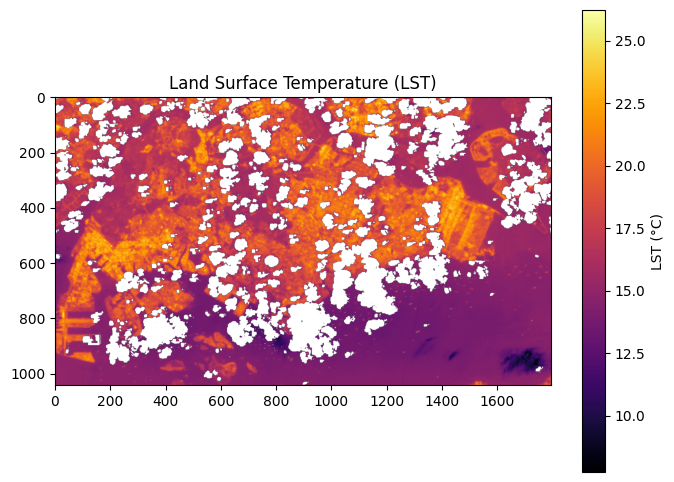

In [ ]:
from google.colab import drive
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Mount Google Drive
drive.mount('/content/drive')

# Step 2: Set file path (modify if needed)
tif_path = "/content/drive/My Drive/GEE_landsat9/LST_Singapore_2023-04-12.tif"  # Update filename

# Step 3: Open the GeoTIFF file and read data
with rasterio.open(tif_path) as dataset:
    lst_data = dataset.read(1)  # Read the first (and only) band
    nodata_value = dataset.nodata  # Get NoData value

# Step 4: Remove NoData values for analysis
lst_data = np.where(lst_data == nodata_value, np.nan, lst_data)

# Step 5: Display LST statistics
print(f"LST Min: {np.nanmin(lst_data):.2f} °C")
print(f"LST Max: {np.nanmax(lst_data):.2f} °C")
print(f"LST Mean: {np.nanmean(lst_data):.2f} °C")

# Step 6: Visualize LST values
plt.figure(figsize=(8,6))
plt.imshow(lst_data, cmap="inferno")
plt.colorbar(label="LST (°C)")
plt.title("Land Surface Temperature (LST)")
plt.show()
